Variant quality

In [4]:
# load tidyverse package
library(tidyverse)

ERROR: Error: package or namespace load failed for ‘tidyverse’:
 .onAttach failed in attachNamespace() for 'tidyverse', details:
  call: NULL
  error: package or namespace load failed for ‘stringr’ in dyn.load(file, DLLpath = DLLpath, ...):
 unable to load shared object '/data/proj2/home/students/u.srinivasan/.conda/envs/mamba/envs/r441/lib/R/library/stringi/libs/stringi.so':
  libicui18n.so.58: cannot open shared object file: No such file or directory


In [1]:
qual_stats_dir="/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/VCFs/vcf_gz/vcg.gz.r3/vcfs_w_newmissfilt_newpops/depth_allelebal/qual_stats_final"

setwd(qual_stats_dir)
prefix <- "Pf3D7_dep10_90x_AB0.9_qcpass_White_Allchr"  # Specify your prefix

Rows: 479806 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): chr
dbl (2): pos, qual

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“Removed 434441 rows containing non-finite outside the scale range
(`stat_density()`).”


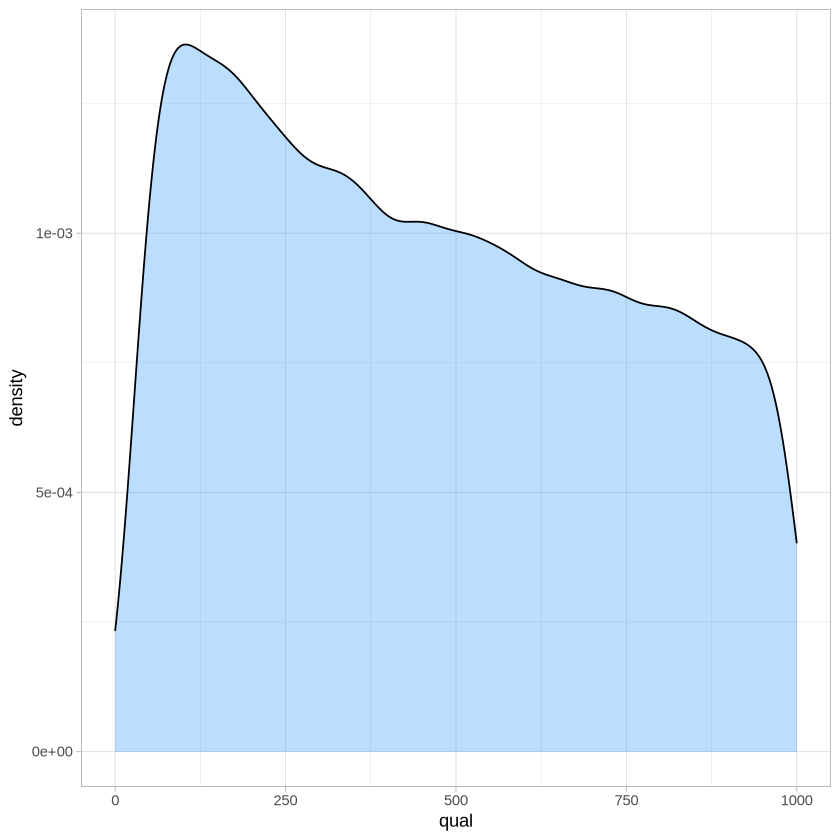

In [9]:

var_qual <- read_delim(paste0(prefix, ".lqual"), delim = "\t",
           col_names = c("chr", "pos", "qual"), skip = 1)

a <- ggplot(var_qual, aes(qual)) +
    geom_density(fill = "dodgerblue1", colour = "black", alpha = 0.3) +
    xlim(0, 1e3)
a + theme_light()


Variant mean depth

Rows: 479806 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): chr
dbl (3): pos, mean_depth, var_depth

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


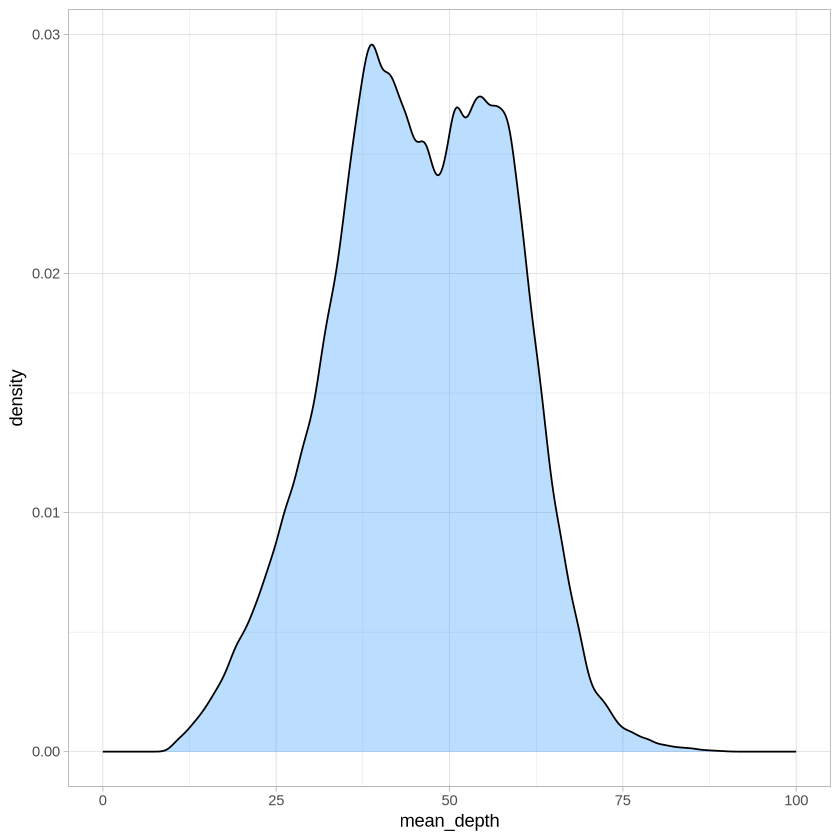

In [10]:
var_depth <- read_delim(paste0(prefix, ".ldepth.mean"), delim = "\t",
           col_names = c("chr", "pos", "mean_depth", "var_depth"), skip = 1)
        
a <- ggplot(var_depth, aes(mean_depth)) + geom_density(fill = "dodgerblue1", colour = "black", alpha = 0.3)

a + theme_light() + xlim(0, 100)



In [4]:

summary(var_depth$mean_depth)


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  10.01   36.91   45.92   45.76   55.52   89.87 

Variant missingness

In [5]:

suffix <- "\\.lqual$"  # Define the suffix
filename <-   # Combine prefix and suffix

var_miss <- read_delim(paste0(prefix, ".lmiss"), delim = "\t",
                       col_names = c("chr", "pos", "nchr", "nfiltered", "nmiss", "fmiss"), skip = 1)


Rows: 479806 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): chr
dbl (5): pos, nchr, nfiltered, nmiss, fmiss

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.000000 0.000000 0.000000 0.001979 0.000000 0.099788 

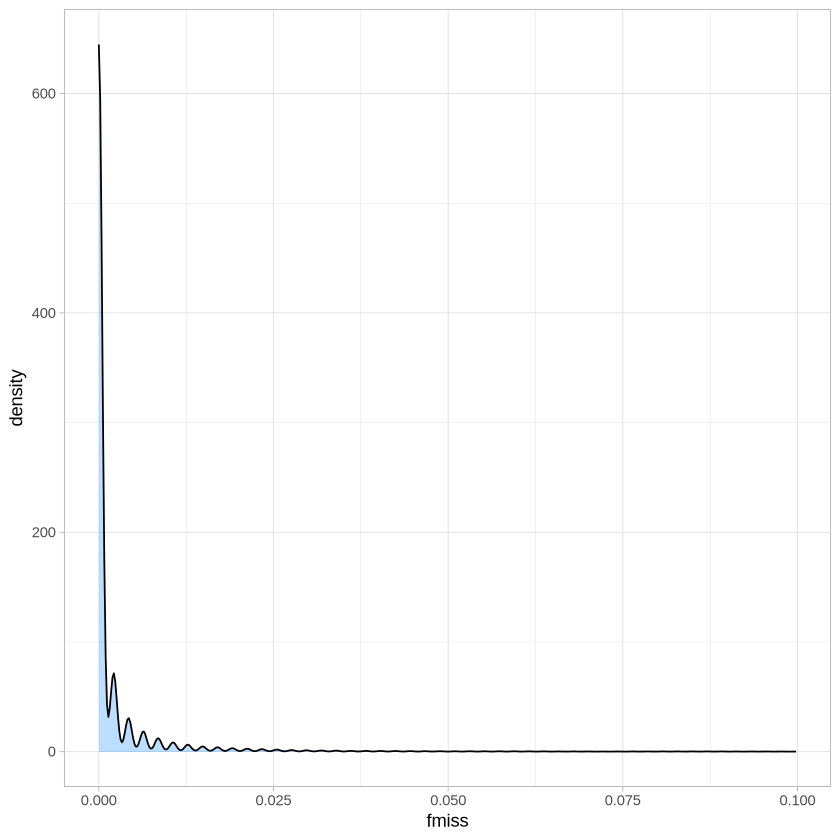

In [6]:
a <- ggplot(var_miss, aes(fmiss)) + geom_density(fill = "dodgerblue1", colour = "black", alpha = 0.3)
a + theme_light()# +xlim(0,0.1)
summary(var_miss$fmiss)

In [8]:
summary(var_miss$fmiss)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.000000 0.000000 0.000000 0.001979 0.000000 0.099788 

Minor allele frequency

In [7]:
var_freq <- read_delim(paste0(prefix, ".frq"), delim = "\t",
                       col_names = c("chr", "pos", "nalleles", "nchr", "a1", "a2"), skip = 1)

# find minor allele frequency
var_freq$maf <- var_freq %>% select(a1, a2) %>% apply(1, function(z) min(z))

a <- ggplot(var_freq, aes(maf)) + geom_density(fill = "dodgerblue1", colour = "black", alpha = 0.3)
a + theme_light() +xlim(0,0.002)


Rows: 479806 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): chr
dbl (5): pos, nalleles, nchr, a1, a2

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


ERROR: Error in select(., a1, a2): could not find function "select"


In [62]:
summary(var_freq$maf)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.000000 0.000000 0.000000 0.004315 0.000000 0.498938 

Individual based statistics

Rows: 448 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): ind
dbl (2): nsites, depth



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


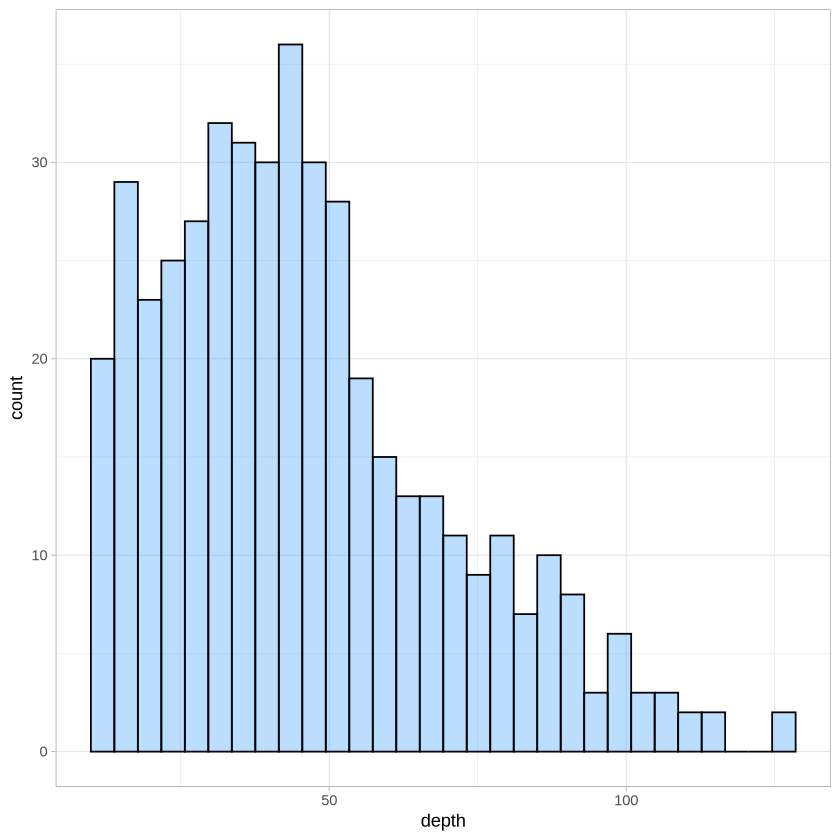

In [8]:
ind_depth <- read_delim(paste0(prefix, ".idepth"), delim = "\t",
                        col_names = c("ind", "nsites", "depth"), skip = 1)

a <- ggplot(ind_depth, aes(depth)) + geom_histogram(fill = "dodgerblue1", colour = "black", alpha = 0.3)
a + theme_light()



In [13]:
highdepthinds <- ind_depth %>% 
  filter(depth > 20 & depth < 90) %>% 
  dplyr::select(ind)


In [ ]:
summary(ind_depth$depth) # mean is 45 so half ~22 and below is taken as lowr bound of depth

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   6.73   26.86   41.64   45.76   58.59  172.66 

Proportion of missing data per individual

Rows: 448 Columns: 5


── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): ind
dbl (4): ndata, nfiltered, nmiss, fmiss

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


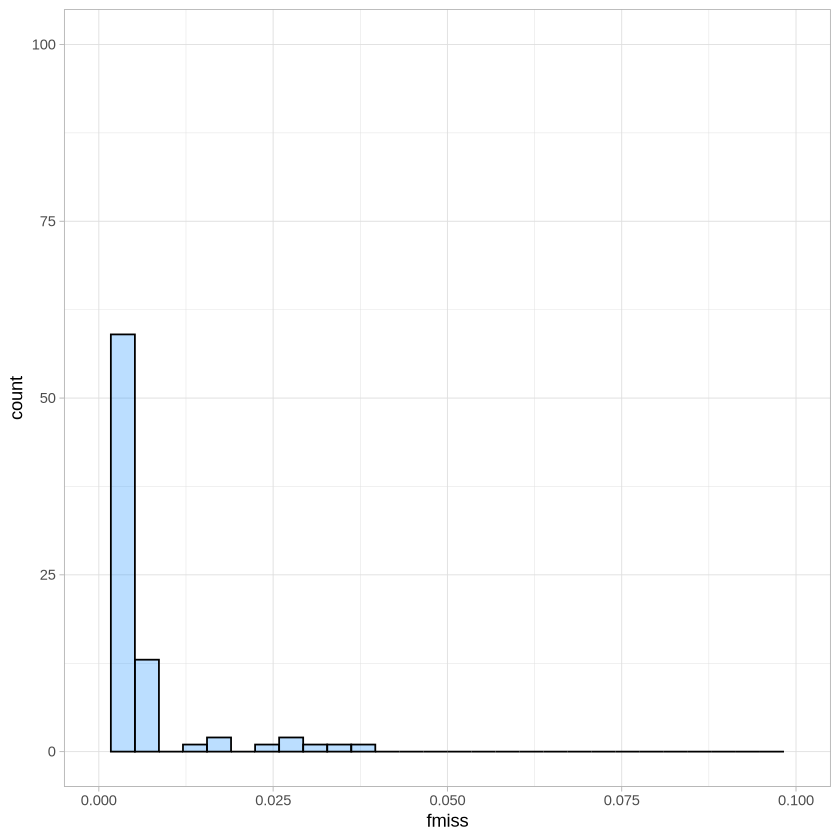

In [9]:
ind_miss  <- read_delim(paste0(prefix, ".imiss"), delim = "\t",
                        col_names = c("ind", "ndata", "nfiltered", "nmiss", "fmiss"), skip = 1)

a <- ggplot(ind_miss, aes(fmiss)) + geom_histogram(fill = "dodgerblue1", colour = "black", alpha = 0.3)
a + theme_light()+xlim(0,0.1)+ylim(0,100)

In [ ]:
highdepthinds

Heterozygosity and inbreeding coefficient per individual

Rows: 448 Columns: 5


── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): ind
dbl (4): ho, he, nsites, f

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


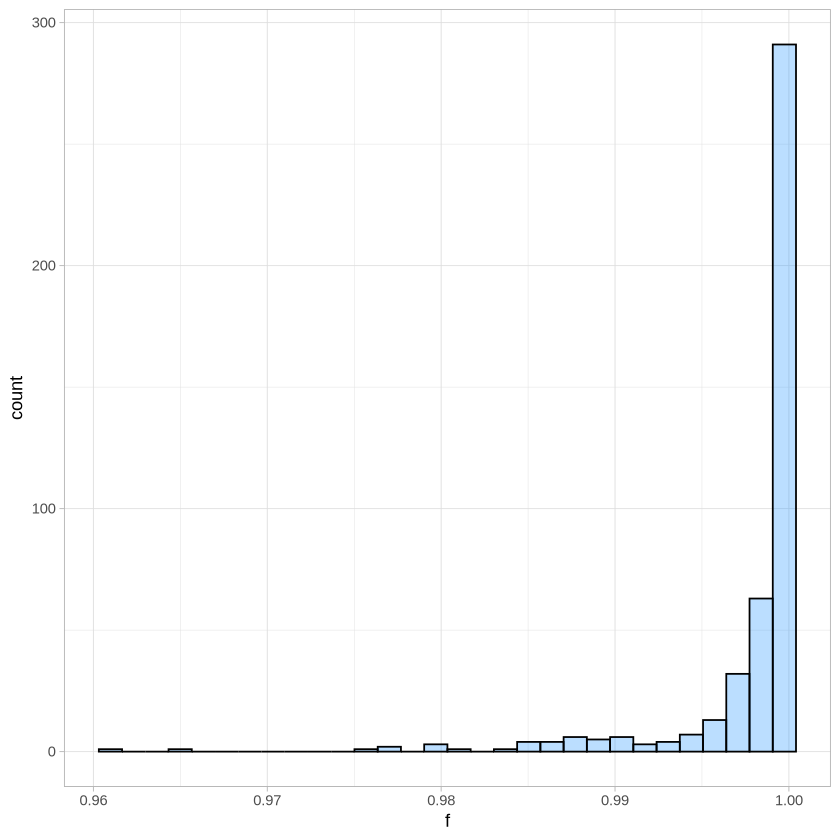

In [10]:
ind_het <- read_delim(paste0(prefix, ".het"), delim = "\t",
           col_names = c("ind","ho", "he", "nsites", "f"), skip = 1)


a <- ggplot(ind_het, aes(f)) + geom_histogram(fill = "dodgerblue1", colour = "black", alpha = 0.3)
a + theme_light()